# Modeling Dependency 

##### What has changed now?
- Data set is Tranco
- We take to account  PARENT_OF relationship  for the names in the list
- We take to account ALIAS_OF relationship for the names in the list

##### Imports and Configurations.

In [1]:
from IPython.display import clear_output
from IPython.display import display
from urllib.parse import urljoin
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from bs4 import BeautifulSoup
from pathlib import Path
import pandas as pd
import requests
import numpy as np
import time
import math
import csv
import re
import os

In [2]:
fig_dir = Path.cwd().parent / "outputs" / "figures" / "tranco_list" 
fig_dir.mkdir(parents=True, exist_ok=True)

In [20]:
# Database connection details
URI = 'neo4j://localhost:7687'
AUTH = ('neo4j', 'password')
db = GraphDatabase.driver(URI, auth=AUTH)
db.verify_connectivity()


#### Data Selection and Understanding

##### Testing Database connection; Checking the count of Domain in the Tranco List and thier label types

In [ ]:
# Query to count the number of domains and their labels in the Tranco top 1M ranking
query = """
MATCH (x)-[:RANK]-(:Ranking{name:"Tranco top 1M"})
RETURN
count ( x) as domain_count ,
Collect(DISTINCT labels(x)) as label
"""

records, _, keys = db.execute_query(query)
query_result = pd.DataFrame(records, columns=keys)
query_result

,domain_count,label
0,1000000,[[DomainName]]


One million records  all of label DomainName

**Qn**
*By Definition there ALIAS relationship is between hostnames, Can we capture ALIAS_OF Reletionship between Domain*

#### ALIAS_OF

In [ ]:
query = """
MATCH p =(x:DomainName)-[:ALIAS_OF]-(y)
RETURN count(DISTINCT p) as relationship_count
"""

records, _, keys = db.execute_query(query)
query_result = pd.DataFrame(records, columns=keys)
query_result

,relationship_count
0,0


There is no ALIAS_OF relationship that involve DomainNames Nodes

#### PARENT

Logic IF PARENT = TLD igonre else find the dependency of the parent

1. GET a list of TLD by iana 
2. GET PARENTS  from the Tranco Domans

    i. How many Domains have PARENTS
    
   ii. How many Parent are TLD 

###### GET a list of TLD

In [ ]:
# Get TLD list with their type from iana.
url = "https://www.iana.org/domains/root/db"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

rows = []
for tr in soup.select("table tbody tr"):
    tds = tr.find_all("td")
    if len(tds) >= 3:
        a = tds[0].find("a")
        Domain = a.get_text(strip=True) if a else tds[0].get_text(strip=True)
        href = a["href"] if a and a.has_attr("href") else None
        
        punycode = None
        if href:
            filename = href.split("/")[-1]
            punycode = filename.replace(".html", "")
        else:
            full_url = None

        rows.append({
            "Domain": Domain,
            "tld": punycode,
            "type": tds[1].get_text(" ", strip=True),
            "manager": tds[2].get_text(" ", strip=True),
        })

iana_list = pd.DataFrame(rows)
print("Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type")
print(iana_list[iana_list["Domain"] == ".餐厅"])
print("\n")
iana_list

Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type
     Domain          tld     type                                     manager
1481    .餐厅  xn--imr513n  generic  Internet DotTrademark Organisation Limited




,Domain,tld,type,manager
0,.aaa,aaa,generic,"American Automobile Association, Inc."
1,.aarp,aarp,generic,AARP
2,.abarth,abarth,generic,Not assigned
3,.abb,abb,generic,ABB Ltd
4,.abbott,abbott,generic,"Abbott Laboratories, Inc."
...,...,...,...,...
1589,.zippo,zippo,generic,Not assigned
1590,.zm,zm,country-code,Zambia Information and Communications Technolo...
1591,.zone,zone,generic,"Binky Moon, LLC"
1592,.zuerich,zuerich,generic,Kanton Zürich (Canton of Zurich)


In [ ]:
# Web scraping the list of TLDs from the AICANN public suffix list  Version // VERSION: 2026-04-24_06-48-12_UTC

URL = "https://publicsuffix.org/list/public_suffix_list.dat"

BEGIN = "// ===BEGIN ICANN DOMAINS==="
END = "// ===END ICANN DOMAINS==="

def to_punycode(rule: str) -> str:
    """
    Convert Unicode public suffix rule to IDNA/punycode.
    Keeps PSL markers: wildcard (*) and exception (!).
    """
    prefix = ""
    if rule.startswith("!"):
        prefix = "!"
        rule = rule[1:]

    labels = rule.split(".")
    encoded_labels = []

    for label in labels:
        if label == "*":
            encoded_labels.append(label)
        else:
            encoded_labels.append(label.encode("idna").decode("ascii"))

    return prefix + ".".join(encoded_labels)


def extract_icann_public_suffixes(url: str = URL) -> pd.DataFrame:
    response = requests.get(url, timeout=30)
    response.encoding = "utf-8"
    response.raise_for_status()

    inside_icann = False
    records = []

    for raw_line in response.text.splitlines():
        line = raw_line.strip()

        if line == BEGIN:
            inside_icann = True
            continue

        if line == END:
            break

        if not inside_icann:
            continue

        # ignore empty lines and comments
        if not line or line.startswith("//"):
            continue

        records.append({
            "tld": to_punycode(line),
            "type": "public_suffixlist"
        })

    return pd.DataFrame(records)


public_suffix_list_tld_df = extract_icann_public_suffixes()



In [ ]:
# Example with RU
print(public_suffix_list_tld_df[public_suffix_list_tld_df["type"].str.endswith(".xn--90a3ac") | (public_suffix_list_tld_df["tld"] == "xn--90a3ac")])

             tld               type
5752  xn--90a3ac  public_suffixlist


#### Understanding the Data

##### : TLD Distribution

In [ ]:
query = """
MATCH (domain)-[:RANK]->(:Ranking{name:"Tranco top 1M"})
RETURN domain.name as domain
"""

records, _, keys = db.execute_query(query)
names_df = pd.DataFrame(records, columns=keys)

names_df.head(2)

,domain
0,kunlunea.com
1,link-988betgcr.pro


In [ ]:
#extracting tld part on the names
names_df["tld"]=names_df["domain"].str.extract(r"\.([^.]+)$")
print("Different TLD present in the dataset",names_df["tld"].nunique())

Different TLD present in the dataset 1051


In [ ]:
names_df.shape

(1000000, 2)

In [ ]:
names_df

,domain,tld
0,kunlunea.com,com
1,link-988betgcr.pro,pro
2,fiberflex.dk,dk
3,kiaspecialtools.com,com
4,quiz4dgg.space,space
...,...,...
999995,proteste.pt,pt
999996,networkrail.co.uk,uk
999997,cubicmotion.com,com
999998,queniuwx.com,com


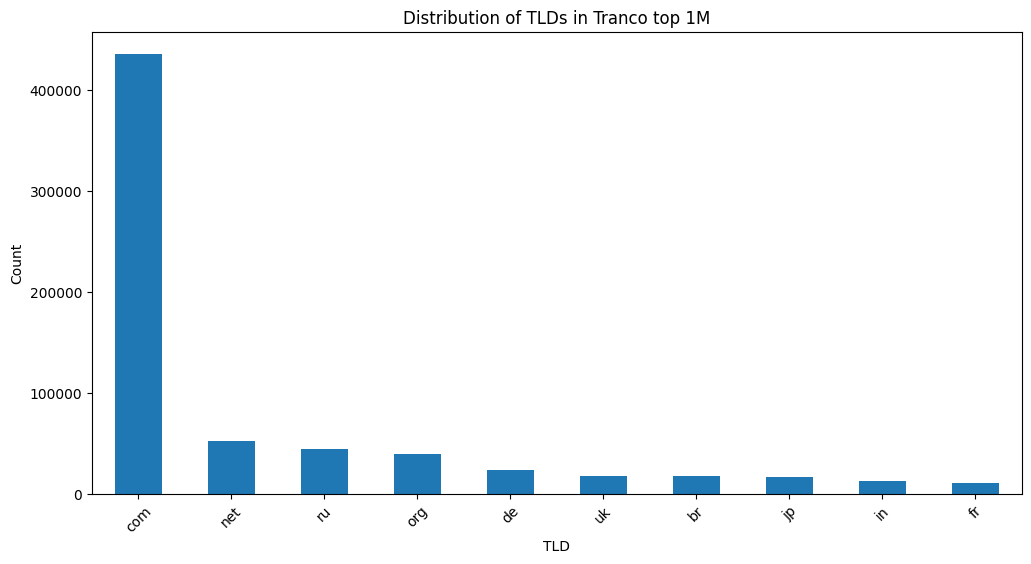

In [ ]:
tld_grouped_size_df = names_df["tld"].value_counts(dropna=False)
top_10_tlds = tld_grouped_size_df.head(10)
top_10_tlds.plot(kind="bar", figsize=(12, 6), title="Distribution of TLDs in Tranco top 1M")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### : PARENT_STATUS
How many domains have parents relations ?, how many of those parent relations are TLD?, and how many are not?.

Answers to those question will determine how we want to  find depdendecy  when looking at the TRANCO TOP 1M Data.

In [ ]:
iana_list_TLD = iana_list["tld"].dropna().tolist()
query = """

MATCH (domain)-[:RANK]->(:Ranking {name:"Tranco top 1M"})
OPTIONAL MATCH (parent)<-[:PARENT]-(domain)

WITH domain,
     collect(DISTINCT parent.name) AS parents

WITH domain,
     CASE
        WHEN size(parents) = 0 OR parents = [null]
            THEN "parent_rel_does_not_exist"

        WHEN any(p IN parents WHERE p IN $iana_list_TLD) OR any(p IN parents WHERE p IN $public_suffix_list_TLD)
            THEN "TLD"


        ELSE "NOT_TLD"
     END AS p_status

RETURN p_status, count(DISTINCT domain) AS count

"""

records, _, keys = db.execute_query(query, iana_list_TLD=iana_list_TLD, public_suffix_list_TLD=public_suffix_list_tld_df["tld"].tolist())
query_result = pd.DataFrame(records, columns=keys)
query_result

,p_status,count
0,TLD,946104
1,parent_rel_does_not_exist,53894
2,NOT_TLD,2


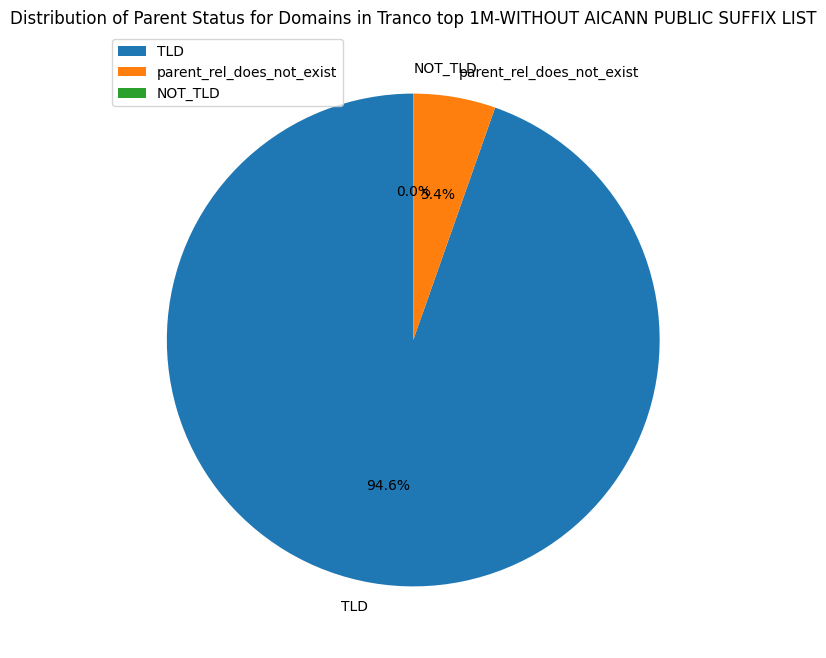

In [ ]:
p_status_distribution = query_result.plot.pie(y='count', labels=query_result['p_status'], autopct='%1.1f%%', startangle=90, figsize=(8, 8), title='Distribution of Parent Status for Domains in Tranco top 1M-WITHOUT AICANN PUBLIC SUFFIX LIST')
p_status_distribution.get_figure().savefig(fig_dir / "parent_status_distribution_tranco_list_with_public_suffix_list.png", bbox_inches='tight')

Because of the data distribution I decided to have three different function to fetch dependency since only 0.8% of the names have parent that are not TLD

Functions / queries
1. parent_not_tld
2. parent_tld
3. parent_rel_not_found

##### Createing a dataframe 


|domain|p_status|



In [ ]:
iana_list_TLD = iana_list["tld"].dropna().tolist()
query = """
MATCH (domain)-[:RANK]->(:Ranking{name:"Tranco top 1M"})
OPTIONAL MATCH (parent)<-[:PARENT]-(domain)
WITH domain,
     collect(DISTINCT parent.name) AS parents

WITH domain,
     CASE
        WHEN size(parents) = 0 OR parents = [null]
            THEN "parent_rel_does_not_exist"

        WHEN any(p IN parents WHERE p IN $iana_list_TLD) OR any(p IN parents WHERE p IN $public_suffix_list_TLD)
            THEN "TLD"


        ELSE "NOT_TLD"
     END AS p_status


RETURN domain.name as domain,p_status as p_status

"""

records, _, keys = db.execute_query(query, iana_list_TLD=iana_list_TLD, public_suffix_list_TLD=public_suffix_list_tld_df["tld"].tolist())
names_pstatus_df = pd.DataFrame(records, columns=keys)
names_pstatus_df.head(10)

,domain,p_status
0,kunlunea.com,TLD
1,link-988betgcr.pro,TLD
2,fiberflex.dk,parent_rel_does_not_exist
3,kiaspecialtools.com,TLD
4,quiz4dgg.space,TLD
5,edcsr.com,TLD
6,agenbpjs777.info,TLD
7,j399j39y6.com,TLD
8,auto-power-girl.com,TLD
9,pepsico.africa,TLD


In [ ]:
names_pstatus_df.shape

(1000000, 2)

In [ ]:
names_df.head(2)

,domain,tld
0,kunlunea.com,com
1,link-988betgcr.pro,pro


In [ ]:
print(names_df[names_df["tld"].eq("onion")])

           domain    tld
994630  com.onion  onion


##### Create data frame 
**|domain|TLD|type|p-status|**
Data frame will help in grouping the Tranco-Dataset, When analyzing Dependency

In [ ]:
# Merge names and tld with type from iana list
names_df = names_df.merge(
    iana_list[["tld", "type"]],
    on="tld",
    how="left"
)

names_df = names_df.merge(
    public_suffix_list_tld_df[["tld", "type"]],
    on="tld",
    how="left",
    suffixes=("", "_psl")
)

names_df["type"] = names_df["type"].fillna(names_df["type_psl"])

names_df = names_df.drop(columns=["type_psl"])


In [ ]:
print(names_df[names_df["tld"].eq("onion")])

           domain    tld               type                   p_status
994630  com.onion  onion  public_suffixlist  parent_rel_does_not_exist


In [ ]:
names_df.head(10)


,domain,tld,type
0,kunlunea.com,com,generic
1,link-988betgcr.pro,pro,generic-restricted
2,fiberflex.dk,dk,country-code
3,kiaspecialtools.com,com,generic
4,quiz4dgg.space,space,generic
5,edcsr.com,com,generic
6,agenbpjs777.info,info,generic
7,j399j39y6.com,com,generic
8,auto-power-girl.com,com,generic
9,pepsico.africa,africa,generic


In [ ]:
names_df.isna().any()

domain    False
tld       False
type      False
dtype: bool

In [ ]:
names_df.isna().sum()

domain    0
tld       0
type      0
dtype: int64

In [ ]:
names_df.isna().any()

domain    False
tld       False
type      False
dtype: bool

In [ ]:
# Merging names_df (Categorized names) with names_pstatus
names_df = names_df.merge(names_pstatus_df, on="domain", how="left")

In [ ]:
names_df.head(10)

,domain,tld,type,p_status
0,kunlunea.com,com,generic,TLD
1,link-988betgcr.pro,pro,generic-restricted,TLD
2,fiberflex.dk,dk,country-code,parent_rel_does_not_exist
3,kiaspecialtools.com,com,generic,TLD
4,quiz4dgg.space,space,generic,TLD
5,edcsr.com,com,generic,TLD
6,agenbpjs777.info,info,generic,TLD
7,j399j39y6.com,com,generic,TLD
8,auto-power-girl.com,com,generic,TLD
9,pepsico.africa,africa,generic,TLD


In [ ]:
# Saving the categorized names to parquet file for future use
try:
    out_dir = Path.cwd().parent / 'data' / 'names'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / 'tranco_categorized_names.parquet'
    names_df.to_parquet(out_path, index=False)
    
except Exception as e:
    print(f"failed:{e}")

#### Finding Dependency 

##### Loading Categorized Names

In [4]:
# From now on we will be using categorized name list saved  in   data\names\categorized_names.parquet
file_path = Path.cwd().parent / 'data' / 'names' /  'tranco_categorized_names.parquet'
names_tldtype_df = pd.read_parquet(file_path)
names_tldtype_df.head(2)

,domain,tld,type,p_status
0,kunlunea.com,com,generic,TLD
1,link-988betgcr.pro,pro,generic-restricted,TLD


##### Functions & Queries

In [24]:
# Defining folders to save the results of the queries for future use
try:
    base_dir = Path.cwd().parent / "data" / "result" / "tranco_list"
    base_dir.mkdir(parents=True, exist_ok=True)
except Exception as e:
    print(f"failed:{e}")

In [25]:
query_no_parent = """
      MATCH (start:DomainName {name: $domain_name})

        
      CALL(start) {

            CALL apoc.path.expandConfig(start, {
                relationshipFilter: "MANAGED_BY_SOURCE_OPENINTEL>|PART_OF_SOURCE_OPENINTEL>",
                minLevel: 1,
                labelFilter: "+DomainName|>HostName|>AuthoritativeNameServer|/HAS_GLUE_SOURCE_OPENINTEL",
                uniqueness: "NODE_PATH",
                bfs: true
            })
            YIELD path
            WITH path, nodes(path)[-1] AS leafnode
            WHERE leafnode:HAS_GLUE_SOURCE_OPENINTEL
            RETURN collect(DISTINCT path) AS valid_paths
        }

        
        CALL (start, valid_paths) {
            UNWIND valid_paths AS p
            RETURN
            collect({
            start_domain: start.name,
            name_server_count: size([node IN nodes(p) WHERE node:AuthoritativeNameServer]),
            name_servers: [node IN nodes(p) WHERE node:AuthoritativeNameServer | node.name]
            }) AS path_rows
        }
        
        CALL (start, valid_paths){ 
            UNWIND valid_paths AS p
            WITH start, nodes(p) AS ns
            UNWIND range(0, size(ns) - 2) AS i
            WITH start, ns, i, ns[i] AS a, ns[i+1] AS b,
            CASE WHEN i + 2 < size(ns) THEN ns[i+2] ELSE null END AS c
            WHERE a:DomainName AND b:AuthoritativeNameServer
        
            WITH start, a.name AS source, c.name AS target_zone, collect(DISTINCT b.name) AS via_nameservers
        
            RETURN
            collect({
                source: source,
                target_zone: target_zone,
                via_nameservers: via_nameservers
            }) AS dependencies,
            collect(via_nameservers) AS ns_lists
        }
        
        WITH start,path_rows, dependencies, ns_lists,
                apoc.coll.toSet(apoc.coll.flatten(ns_lists)) AS all_unique_ns
        
        WITH start,path_rows, dependencies,all_unique_ns
        UNWIND path_rows as row

        
        RETURN
            DISTINCT
            start.name AS domain,
            min(row.name_server_count) as short_path_size,
            max(row.name_server_count) as long_path_size,
            count(row)  as available_paths,
            avg(row.name_server_count) as average_path_size,
            size(all_unique_ns) AS TCB,
            all_unique_ns as domain_unique_ns,
            path_rows as domain_path_rows,
            dependencies
        """

In [26]:
query_with_parent = """
        MATCH (start:DomainName {name: $domain_name})-[:PARENT]->(parent)

        WITH DISTINCT start, parent

        CALL {
            WITH parent
            CALL apoc.path.expandConfig(parent, {
                relationshipFilter: "MANAGED_BY_SOURCE_OPENINTEL>|PART_OF_SOURCE_OPENINTEL>",
                minLevel: 1,
                labelFilter: "+DomainName|>HostName|>AuthoritativeNameServer|/HAS_GLUE_SOURCE_OPENINTEL",
                uniqueness: "NODE_PATH",
                bfs: true
            })
            YIELD path
            WITH path, nodes(path)[-1] AS leafnode
            WHERE leafnode:HAS_GLUE_SOURCE_OPENINTEL
            RETURN collect(DISTINCT path) AS parent_paths
        }

        CALL {
            WITH start
            CALL apoc.path.expandConfig(start, {
                relationshipFilter: "MANAGED_BY_SOURCE_OPENINTEL>|PART_OF_SOURCE_OPENINTEL>",
                minLevel: 1,
                labelFilter: "+DomainName|>HostName|>AuthoritativeNameServer|/HAS_GLUE_SOURCE_OPENINTEL",
                uniqueness: "NODE_PATH",
                bfs: true
            })
            YIELD path
            WITH path, nodes(path)[-1] AS leafnode
            WHERE leafnode:HAS_GLUE_SOURCE_OPENINTEL
            RETURN collect(DISTINCT path) AS child_paths
        }

        CALL {
            WITH start, parent, child_paths
            UNWIND child_paths AS p
            RETURN collect({
                domain: start.name,
                parent: parent.name,
                name_server_count: size([node IN nodes(p) WHERE node:AuthoritativeNameServer]),
                path: [node IN nodes(p) | node.name]
            }) AS child_path_rows
        }

        CALL {
            WITH start, parent, parent_paths
            UNWIND parent_paths AS p
            RETURN collect({
                domain: parent.name,
                parent_of: start.name,
                name_server_count: size([node IN nodes(p) WHERE node:AuthoritativeNameServer]),
                path: [node IN nodes(p) | node.name]
            }) AS parent_path_rows
        }

        CALL {
            WITH child_paths, parent_paths

            CALL {
                WITH child_paths
                UNWIND child_paths AS p
                WITH nodes(p) AS ns
                UNWIND range(0, size(ns) - 2) AS i
                WITH ns[i] AS a, ns[i+1] AS b,
                    CASE WHEN i + 2 < size(ns) THEN ns[i+2] ELSE null END AS c
                WHERE a:DomainName AND b:AuthoritativeNameServer
                RETURN
                    "child" AS side,
                    a.name AS source,
                    c.name AS target_zone,
                    collect(DISTINCT b.name) AS via_nameservers

                UNION

                WITH parent_paths
                UNWIND parent_paths AS p
                WITH nodes(p) AS ns
                UNWIND range(0, size(ns) - 2) AS i
                WITH ns[i] AS a, ns[i+1] AS b,
                    CASE WHEN i + 2 < size(ns) THEN ns[i+2] ELSE null END AS c
                WHERE a:DomainName AND b:AuthoritativeNameServer
                RETURN
                    "parent" AS side,
                    a.name AS source,
                    c.name AS target_zone,
                    collect(DISTINCT b.name) AS via_nameservers
            }

            RETURN
                collect({
                    side: side,
                    source: source,
                    target_zone: target_zone,
                    via_nameservers: via_nameservers
                }) AS dependencies,
                collect(CASE WHEN side = "child" THEN via_nameservers ELSE [] END) AS child_ns_lists,
                collect(CASE WHEN side = "parent" THEN via_nameservers ELSE [] END) AS parent_ns_lists,
                apoc.coll.toSet(apoc.coll.flatten(collect(via_nameservers))) AS all_unique_ns
        }

        WITH
            start,
            parent,
            child_path_rows,
            parent_path_rows,
            dependencies,
            all_unique_ns,
            apoc.coll.toSet(apoc.coll.flatten(child_ns_lists)) AS all_child_unique_ns,
            apoc.coll.toSet(apoc.coll.flatten(parent_ns_lists)) AS all_parent_unique_ns

        UNWIND child_path_rows AS row
        UNWIND parent_path_rows as p_row

        RETURN
            start.name AS domain,
            parent.name AS parent,
            min(row.name_server_count) AS short_path_size,
            max(row.name_server_count) AS long_path_size,
            count(row) AS available_paths,
            avg(p_row.name_server_count) AS average_path_size,
            min(p_row.name_server_count) AS short_path_size_via_parent,
            max(p_row.name_server_count) AS long_path_size_via_parent,
            count(p_row) AS available_paths_via_parent,
            avg(p_row.name_server_count) AS average_path_size_via_parent,
            size(all_child_unique_ns) AS TCB,
            size(all_parent_unique_ns) AS parent_TCB,
            size(all_unique_ns) AS TCB_with_parent,
            all_child_unique_ns as domain_unique_ns,
            all_parent_unique_ns,
            child_path_rows as domain_path_rows,
            parent_path_rows,
            dependencies
        """

In [27]:
#Finding Dipendency
def finding_dependency(db, list_of_names, query, output_path, chunk_size=None ,p_status=None,overwrite=True):
    """
    Run dependency query for a list of domains.

    If chunk_size is None:
        saves one parquet file to output_path

    If chunk_size is given:
        saves chunk parquet files inside output_path directory
    """

    output_path = Path(output_path)

    all_rows = []
    chunk_rows = []

    total = len(list_of_names)
    last_update = time.time()
    chunk_id = 1

    if chunk_size is not None:
        output_path.mkdir(parents=True, exist_ok=True)
    else:
        output_path.parent.mkdir(parents=True, exist_ok=True)

    for i, domain in enumerate(list_of_names, start=1):
        rows = fetch_paths(db, domain, query, p_status)

        if chunk_size is None:
            all_rows.extend(rows)
        else:
            chunk_rows.extend(rows)

            if len(chunk_rows) >= chunk_size:
                chunk_file = output_path / f"chunk_{chunk_id:05d}.parquet"

                if chunk_file.exists() and not overwrite:
                    raise FileExistsError(f"{chunk_file} already exists")

                pd.DataFrame(chunk_rows).to_parquet(chunk_file, index=False)

                chunk_rows = []
                chunk_id += 1

        now = time.time()

        if now - last_update >= 2 or i == total:
            clear_output(wait=True)
            print(f"Processing {i}/{total}: {domain}")
            last_update = now

    if chunk_size is None:
        if output_path.exists() and not overwrite:
            raise FileExistsError(f"{output_path} already exists")

        df = pd.DataFrame(all_rows)
        df.to_parquet(output_path, index=False)
        return df

    else:
        if chunk_rows:
            chunk_file = output_path / f"chunk_{chunk_id:05d}.parquet"

            if chunk_file.exists() and not overwrite:
                raise FileExistsError(f"{chunk_file} already exists")

            pd.DataFrame(chunk_rows).to_parquet(chunk_file, index=False)

        return None

# Return raw Neo4j Path objects
def fetch_paths(db, domain_name, query, p_status):
    try:
        records, _, _ = db.execute_query(
            query,
            domain_name=domain_name
        )

        rows = []

        for r in records:
            row = {
                "domain": r.get("domain"),

                "short_path_size": r.get("short_path_size"),
                "long_path_size": r.get("long_path_size"),
                "available_paths": r.get("available_paths"),
                "average_path_size": r.get("average_path_size"),

                "TCB": r.get("TCB"),
                "domain_unique_ns": r.get("domain_unique_ns", []),
                "domain_path_rows": r.get("domain_path_rows", []),
                "dependencies": r.get("dependencies", []),
            }

            if p_status == "withParent":
                row.update({
                    "parent": r.get("parent"),

                    "short_path_size_via_parent": r.get("short_path_size_via_parent"),
                    "long_path_size_via_parent": r.get("long_path_size_via_parent"),
                    "available_paths_via_parent": r.get("available_paths_via_parent"),
                    "average_path_size_via_parent": r.get("average_path_size_via_parent"),

                    "parent_TCB": r.get("parent_TCB"),
                    "TCB_with_parent": r.get("TCB_with_parent"),
                    "all_parent_unique_ns": r.get("all_parent_unique_ns", []),
                    "parent_path_rows": r.get("parent_path_rows", []),
                })

            rows.append(row)

        return rows

    except Exception as e:
        print(f"Failed for {domain_name}: {e}")
        return []

#### Finding Dependency

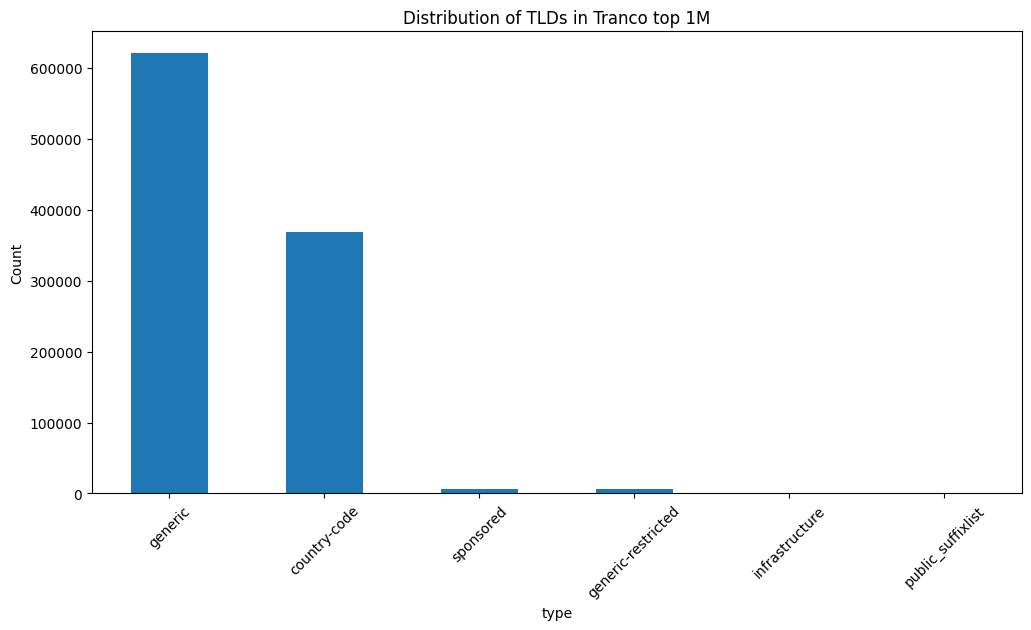

In [11]:
type_grouped_size_df = names_tldtype_df["type"].value_counts(dropna=False)
type_grouped_size_df.head(10)
type_grouped_size_df.plot(kind="bar", figsize=(12, 6), title="Distribution of TLDs in Tranco top 1M")
plt.xlabel("type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [14]:
names_tldtype_df[~names_tldtype_df["p_status"].isin(["parent_rel_does_not_exist", "TLD"])]["domain"].value_counts(dropna=False)

domain
apostille.mygov.bd    1
www.mygov.bd          1
Name: count, dtype: int64

In [13]:
# getting the list do domains based on their type and parent status
ccTLD_domains_list  = names_tldtype_df[(names_tldtype_df["type"]=="country-code") & (names_tldtype_df["p_status"].isin(["TLD", "parent_rel_does_not_exist"]))]["domain"].tolist()
gTLD_domains_list  = names_tldtype_df[(names_tldtype_df["type"]=="generic") & (names_tldtype_df["p_status"].isin(["TLD", "parent_rel_does_not_exist"]))]["domain"].tolist()
sponTLD_domains_list  = names_tldtype_df[(names_tldtype_df["type"]=="sponsored") & (names_tldtype_df["p_status"].isin(["TLD", "parent_rel_does_not_exist"]))]["domain"].tolist()
gen_resTLD_domains_list  = names_tldtype_df[(names_tldtype_df["type"]=="generic-restricted") & (names_tldtype_df["p_status"].isin(["TLD", "parent_rel_does_not_exist"]))]["domain"].tolist()
infrTLD_domains_list  = names_tldtype_df[(names_tldtype_df["type"]=="infrastructure") & (names_tldtype_df["p_status"].isin(["TLD", "parent_rel_does_not_exist"]))]["domain"].tolist()
special_use_domains_list  = names_tldtype_df[(names_tldtype_df["tld"]=="onion")]["domain"].tolist()

#printing the number of domains in each category
print(f"Number of ccTLD domains: {len(ccTLD_domains_list)}")
print(f"Number of gTLD domains: {len(gTLD_domains_list)}")
print(f"Number of sponsored TLD domains: {len(sponTLD_domains_list)}")
print(f"Number of generic-restricted TLD domains: {len(gen_resTLD_domains_list)}")
print(f"Number of infrastructure TLD domains: {len(infrTLD_domains_list)}")
print(f"Number of Special-Use domains: {len(special_use_domains_list)}") 
#total ?
total_domains = len(ccTLD_domains_list) + len(gTLD_domains_list) + len(sponTLD_domains_list) + len(gen_resTLD_domains_list) + len(infrTLD_domains_list) + len(special_use_domains_list)

Number of ccTLD domains: 367652
Number of gTLD domains: 619801
Number of sponsored TLD domains: 6822
Number of generic-restricted TLD domains: 5718
Number of infrastructure TLD domains: 4
Number of Special-Use domains: 1


In [15]:
total_domains

999998

##### ccTLD

In [ ]:
# Getting domain with ccTLD // --- IGNORE --- parents
finding_dependency(
    db,
    ccTLD_domains_list,
    query_no_parent,
    output_path=base_dir / "ccTLD_domains_dependency_no_parent.parquet",
    p_status=None
)

Processing 367652/367652: networkrail.co.uk


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,nlhealthservices.ca,1,1,2,1.0,2,"[ns47.domaincontrol.com, ns48.domaincontrol.com]","[{'name_server_count': 1, 'start_domain': 'nlh...",[{'via_nameservers': ['ns47.domaincontrol.com'...
1,codesubmit.io,1,1,4,1.0,4,"[ns3.dnsimple.com, ns1.dnsimple.com, ns2.dnsim...","[{'name_server_count': 1, 'start_domain': 'cod...","[{'via_nameservers': ['ns3.dnsimple.com', 'ns1..."
2,natalpremiadomarisa.com.br,2,2,12,2.0,8,"[f.sec.dns.br, d.sec.dns.br, b.dns.br, f.dns.b...","[{'name_server_count': 2, 'start_domain': 'nat...","[{'via_nameservers': ['f.sec.dns.br', 'd.sec.d..."
3,hebergement-web.ch,1,1,2,1.0,2,"[ns2.hebergement-web.ch, ns1.hebergement-web.ch]","[{'name_server_count': 1, 'start_domain': 'heb...",[{'via_nameservers': ['ns2.hebergement-web.ch'...
4,pocketsforwomen.co.uk,1,1,2,1.0,2,"[ns2.box.rafletcher.co.uk, ns1.box.rafletcher....","[{'name_server_count': 1, 'start_domain': 'poc...",[{'via_nameservers': ['ns2.box.rafletcher.co.u...
...,...,...,...,...,...,...,...,...,...
346968,blog.ir,1,1,2,1.0,2,"[ns11.blog.ir, ns12.blog.ir]","[{'name_server_count': 1, 'start_domain': 'blo...","[{'via_nameservers': ['ns11.blog.ir', 'ns12.bl..."
346969,cedia.org.ec,1,1,3,1.0,3,"[ns2.cedia.org.ec, ns1.cedia.org.ec, dns.cedia...","[{'name_server_count': 1, 'start_domain': 'ced...","[{'via_nameservers': ['ns2.cedia.org.ec', 'ns1..."
346970,petrovich.ru,1,1,4,1.0,4,"[dns1.petrovich.ru, dns2.obit.ru, dns2.petrovi...","[{'name_server_count': 1, 'start_domain': 'pet...","[{'via_nameservers': ['dns1.petrovich.ru', 'dn..."
346971,proteste.pt,1,1,4,1.0,4,"[ns3.eurodns.com, ns4.eurodns.com, ns1.eurodns...","[{'name_server_count': 1, 'start_domain': 'pro...","[{'via_nameservers': ['ns3.eurodns.com', 'ns4...."


##### general-restricted

In [ ]:
# Getting domain with gen_resTLD // --- IGNORE --- parents
finding_dependency(
    db,
    gen_resTLD_domains_list,
    query_no_parent,
    output_path=base_dir / "gen_resTLD_domains_dependency_no_parent.parquet",
    p_status=None
)

Processing 5718/5718: fdcnet.biz


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,link-988betgcr.pro,1,1,2,1.0,2,"[treasure.ns.cloudflare.com, fred.ns.cloudflar...","[{'name_server_count': 1, 'start_domain': 'lin...",[{'via_nameservers': ['treasure.ns.cloudflare....
1,desabet.pro,1,1,2,1.0,2,"[apollo.ns.cloudflare.com, crystal.ns.cloudfla...","[{'name_server_count': 1, 'start_domain': 'des...",[{'via_nameservers': ['apollo.ns.cloudflare.co...
2,dark2web.biz,1,1,2,1.0,2,"[jeff.ns.cloudflare.com, hera.ns.cloudflare.com]","[{'name_server_count': 1, 'start_domain': 'dar...",[{'via_nameservers': ['jeff.ns.cloudflare.com'...
3,chinesesex.name,1,1,2,1.0,2,"[princess.ns.cloudflare.com, otto.ns.cloudflar...","[{'name_server_count': 1, 'start_domain': 'chi...",[{'via_nameservers': ['princess.ns.cloudflare....
4,4006.name,1,1,2,1.0,2,"[ns2.myhostadmin.net, ns1.myhostadmin.net]","[{'name_server_count': 1, 'start_domain': '400...","[{'via_nameservers': ['ns2.myhostadmin.net', '..."
...,...,...,...,...,...,...,...,...,...
5325,hostia.name,1,1,2,1.0,2,"[dns1.hostia.name, dns3.hostia.name]","[{'name_server_count': 1, 'start_domain': 'hos...","[{'via_nameservers': ['dns1.hostia.name', 'dns..."
5326,insidethegames.biz,1,1,2,1.0,2,"[cory.ns.cloudflare.com, marge.ns.cloudflare.com]","[{'name_server_count': 1, 'start_domain': 'ins...",[{'via_nameservers': ['cory.ns.cloudflare.com'...
5327,awsdns-cn-47.biz,1,1,6,1.0,6,"[g-ns-2000.awsdns-cn-47.biz, g-ns-3757.awsdns-...","[{'name_server_count': 1, 'start_domain': 'aws...",[{'via_nameservers': ['g-ns-2000.awsdns-cn-47....
5328,hashvault.pro,1,1,2,1.0,2,"[ns11.hashvault.pro, ns21.hashvault.pro]","[{'name_server_count': 1, 'start_domain': 'has...","[{'via_nameservers': ['ns11.hashvault.pro', 'n..."


##### sponsored-TLD

In [ ]:
# Getting domain with sponTLD // --- IGNORE --- parents
finding_dependency(
    db,
    sponTLD_domains_list,
    query_no_parent,
    output_path=base_dir / "sponTLD_domains_dependency_no_parent.parquet",
    p_status=None
)

Processing 6822/6822: atf.gov


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,starlightawards.asia,1,1,2,1.000000,2,"[melissa.ns.cloudflare.com, vicky.ns.cloudflar...","[{'name_server_count': 1, 'start_domain': 'sta...",[{'via_nameservers': ['melissa.ns.cloudflare.c...
1,peoplematter.jobs,1,1,2,1.000000,2,"[ns2.peoplematter.jobs, ns1.peoplematter.jobs]","[{'name_server_count': 1, 'start_domain': 'peo...","[{'via_nameservers': ['ns2.peoplematter.jobs',..."
2,ltbbodawa-nsn.gov,1,1,2,1.000000,2,"[ns2.ussignalcom.net, ns1.ussignalcom.net]","[{'name_server_count': 1, 'start_domain': 'ltb...","[{'via_nameservers': ['ns2.ussignalcom.net', '..."
3,sinhgad.edu,1,1,2,1.000000,2,"[demi.ns.cloudflare.com, ray.ns.cloudflare.com]","[{'name_server_count': 1, 'start_domain': 'sin...",[{'via_nameservers': ['demi.ns.cloudflare.com'...
4,c66j.asia,1,1,2,1.000000,2,"[katelyn.ns.cloudflare.com, khalid.ns.cloudfla...","[{'name_server_count': 1, 'start_domain': 'c66...",[{'via_nameservers': ['katelyn.ns.cloudflare.c...
...,...,...,...,...,...,...,...,...,...
6591,irs.gov,1,2,6,1.833333,7,"[ns0022.secondary.cloudflare.com, ns0227.secon...","[{'name_server_count': 1, 'start_domain': 'irs...",[{'via_nameservers': ['ns0022.secondary.cloudf...
6592,clarku.edu,1,1,4,1.000000,4,"[ns2.clarku.edu, ns1.clarku.edu, ns3.clarku.ed...","[{'name_server_count': 1, 'start_domain': 'cla...","[{'via_nameservers': ['ns2.clarku.edu', 'ns1.c..."
6593,rochester.edu,1,1,2,1.000000,2,"[ns-external1.rochester.edu, ns-external2.roch...","[{'name_server_count': 1, 'start_domain': 'roc...",[{'via_nameservers': ['ns-external1.rochester....
6594,udayton.edu,1,2,7,1.571429,8,"[ns-1494.awsdns-58.org, ns-332.awsdns-41.com, ...","[{'name_server_count': 1, 'start_domain': 'uda...","[{'via_nameservers': ['ns-1494.awsdns-58.org',..."


##### infrastructure TLD

In [ ]:
# Getting domain with infrTLD // --- IGNORE --- parents
finding_dependency(
    db,
    infrTLD_domains_list,
    query_no_parent,
    output_path=base_dir / "infrTLD_domains_dependency_no_parent.parquet",
    p_status=None
)

Processing 4/4: ipv4only.arpa


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,as112.arpa,1,1,3,1.0,3,"[a.iana-servers.net, c.iana-servers.net, b.ian...","[{'name_server_count': 1, 'start_domain': 'as1...","[{'via_nameservers': ['a.iana-servers.net', 'c..."
1,in-addr-servers.arpa,1,1,6,1.0,6,"[d.in-addr-servers.arpa, f.in-addr-servers.arp...","[{'name_server_count': 1, 'start_domain': 'in-...",[{'via_nameservers': ['d.in-addr-servers.arpa'...
2,ip6-servers.arpa,1,1,6,1.0,6,"[d.ip6-servers.arpa, c.ip6-servers.arpa, e.ip6...","[{'name_server_count': 1, 'start_domain': 'ip6...","[{'via_nameservers': ['d.ip6-servers.arpa', 'c..."
3,ipv4only.arpa,1,1,4,1.0,4,"[c.iana-servers.net, b.iana-servers.net, a.ian...","[{'name_server_count': 1, 'start_domain': 'ipv...","[{'via_nameservers': ['c.iana-servers.net', 'b..."


##### Special-Use-TLD

In [ ]:
# Getting domain with special_useTLD // --- IGNORE --- parents
finding_dependency(
    db,
    special_use_domains_list,
    query_no_parent,
    output_path=base_dir / "special_use_domains_dependency_no_parent.parquet",
    p_status=None
)

Processing 1/1: com.onion


['com.onion']

##### gTLD


In [ ]:
# Getting domain with gTLD // --- IGNORE --- parents
finding_dependency(
    db,
    gTLD_domains_list,
    query_no_parent,
    output_path=base_dir / "gTLD_domains_dependency_no_parent.parquet",
    p_status=None
)
gTLD_domains_list

Processing 619801/619801: joomag.com


['kunlunea.com',
 'kiaspecialtools.com',
 'quiz4dgg.space',
 'edcsr.com',
 'agenbpjs777.info',
 'j399j39y6.com',
 'auto-power-girl.com',
 'pepsico.africa',
 'ggjudisitusslot777.top',
 'totosaktijt.com',
 'hollywoodlace.com',
 'taxcalc-download.app',
 'fanduel-us.com',
 'zenoxis.digital',
 'ketuabemo03.site',
 'fortmyers-sanibel.com',
 'ramadabet112.com',
 'kadakgardenhotel.com',
 'altyzhub.online',
 'pwcedge-sbs-innov-lab.com',
 'jumbyo.com',
 'aysham.com',
 'trustgroupofcomapnies.com',
 'suara4dscan.com',
 'capitalakan.com',
 'airbet88legend11.xyz',
 'fivetrees.com',
 'katsfm.com',
 'eskipii.com',
 'inworldexpress.com',
 'hidizs.net',
 'tajamballack.com',
 'piabellacasino562.com',
 'miogest.com',
 'galabet1022.com',
 'nahlpgh-mgmt.com',
 'plexiusdns.net',
 'vip-ky-kaiyunesport.com',
 'aquiestoy.chat',
 'e-zydigital.com',
 'nootropicsexpert.com',
 'yasatu.com',
 'rtp-lightkenzo188.shop',
 'themepicker.com',
 'taysenworld.site',
 'kinokordon.chat',
 'wbahis363.com',
 'pesticide.org',
 '

In [ ]:
len(gTLD_domains_list)

619801

##### getting the dependency with parent relationship included

candidates ?



In [ ]:
names_df[~names_df["p_status"].isin(["parent_rel_does_not_exist", "TLD"])]

,domain,tld,type,p_status
269827,apostille.mygov.bd,bd,country-code,NOT_TLD
943016,www.mygov.bd,bd,country-code,NOT_TLD


All candidates are .bd which fals in country-code.

In [16]:
domain_with_parent_rel  = names_tldtype_df[(names_tldtype_df["p_status"]=="NOT_TLD")]["domain"].tolist()


In [17]:
domain_with_parent_rel

['apostille.mygov.bd', 'www.mygov.bd']

In [28]:
finding_dependency(
    db,
    domain_with_parent_rel,
    query_with_parent,
    output_path=base_dir / "domain_with_parent_rel.parquet",
    p_status="withParent"
)


Processing 2/2: www.mygov.bd


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,parent,short_path_size_via_parent,long_path_size_via_parent,available_paths_via_parent,average_path_size_via_parent,parent_TCB,TCB_with_parent,all_parent_unique_ns,parent_path_rows
0,apostille.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'parent': 'mygov.bd', 'name_server_count': 1...","[{'side': 'child', 'via_nameservers': ['melina...",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'name_server_count': 1, 'path': ['mygov.bd',..."
1,www.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'parent': 'mygov.bd', 'name_server_count': 1...","[{'side': 'child', 'via_nameservers': ['melina...",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'name_server_count': 1, 'path': ['mygov.bd',..."
